## 数据加载

In [76]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 200)

# 设置matplotlib字体
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']  # 指定默认字体为黑体
plt.rcParams['axes.unicode_minus'] = False  # 解决保存图像时负号'-'显示为方块

### 单元格合并处理

In [77]:
import openpyxl


# 拆分所有的合并单元格, 并赋予合并之前的值
def unmerge_and_fill_cells(worksheet, columns_to_clean=None):
    # 获取工作表中所有合并单元格的范围
    all_merged_cell_ranges = list(worksheet.merged_cells.ranges)

    # 遍历所有合并单元格的范围
    for merged_cell_range in all_merged_cell_ranges:
        merged_cell = merged_cell_range.start_cell  # 获取合并单元格范围的起始单元格
        worksheet.unmerge_cells(range_string=merged_cell_range.coord)  # 取消合并单元格

        # 遍历合并单元格范围内的每个单元格
        for row_index, col_index in merged_cell_range.cells:
            cell = worksheet.cell(row=row_index, column=col_index)  # 获取当前单元格对象
            cell.value = merged_cell.value  # 将起始单元格的值赋予当前单元格

            # 如果指定了需要清理的列，并且当前单元格在这些列中
            if columns_to_clean and col_index in columns_to_clean:
                cell.value = str(cell.value).replace('\n', '') if cell.value is not None else None  # 去除单元格中的换行符


# 读取原始xlsx文件，拆分并填充单元格，然后生成中间临时文件。
def unmerge_cell(filename, columns_to_clean=None):
    wb = openpyxl.load_workbook(filename)  # 加载原始 Excel 文件
    # 遍历工作簿中的所有工作表
    for sheet_name in wb.sheetnames:
        sheet = wb[sheet_name]  # 获取工作表对象
        unmerge_and_fill_cells(sheet, columns_to_clean)  # 调用 unmerge_and_fill_cells 函数处理当前工作表
    filename = filename.replace(".xlsx", "_temp.xlsx")  # 生成新的文件名，将原始文件名中的 ".xlsx" 替换为 "_temp.xlsx"
    wb.save(filename)  # 保存修改后的工作簿到新的文件
    wb.close()  # 关闭工作簿，释放资源

    return filename  # 返回新的文件名

### 加载附件

In [78]:
ATTACHMENTS_1 = unmerge_cell("附件1.xlsx")
ATTACHMENTS_2 = unmerge_cell("附件2.xlsx")

#### 附件1

In [79]:
# 附件1 乡村的现有耕地
ATTACHMENTS_1_SHEET1 = pd.read_excel(ATTACHMENTS_1,
                                     engine="openpyxl",
                                     sheet_name="乡村的现有耕地",
                                     usecols="A:C",
                                     nrows=55,
                                     header=0)

# 附件1 乡村种植的农作物
ATTACHMENTS_1_SHEET2 = pd.read_excel(ATTACHMENTS_1,
                                     engine="openpyxl",
                                     sheet_name="乡村种植的农作物",
                                     usecols="A:D",
                                     nrows=42,
                                     header=0)

#### 附件2

In [80]:
# 附件2 2023年的农作物种植情况
ATTACHMENTS_2_SHEET1 = pd.read_excel(ATTACHMENTS_2,
                                     engine="openpyxl",
                                     sheet_name="2023年的农作物种植情况",
                                     usecols="A:F",
                                     nrows=88,
                                     header=0)

# 附件2 2023年统计的相关数据
ATTACHMENTS_2_SHEET2 = pd.read_excel(ATTACHMENTS_2,
                                     engine="openpyxl",
                                     sheet_name="2023年统计的相关数据",
                                     usecols="A:H",
                                     nrows=108,
                                     header=0)

### 附件处理

#### 将统计数据 销售单价/(元/斤) 取均值

In [81]:
def average_price(column_data):
    average_values = []
    
    for value in column_data:
        min_val, max_val = map(float, value.split('-')) # 将字符串拆分为最小值和最大值
        # 计算平均值
        average = (min_val + max_val) / 2
        average_values.append(average)
    
    return average_values

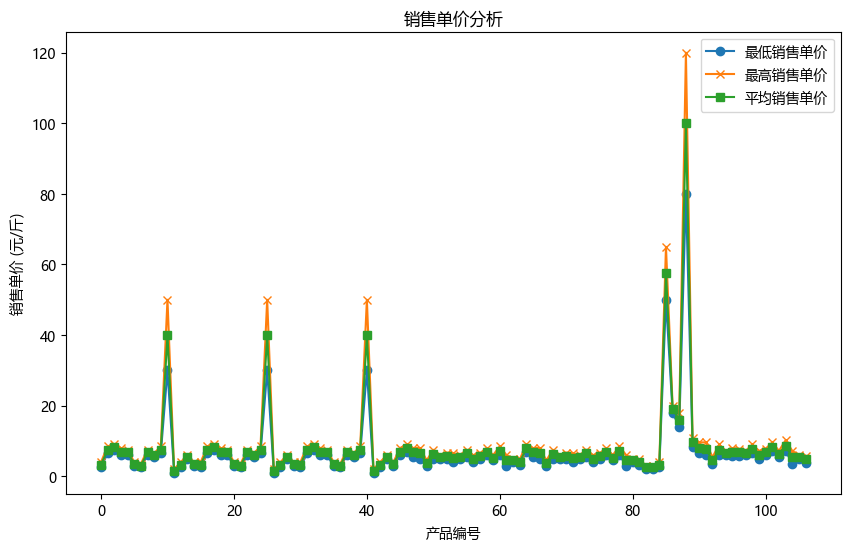

In [82]:
unit_sales_price = ATTACHMENTS_2_SHEET2.iloc[:, 7]  # ['销售单价/(元/斤)']
ATTACHMENTS_2_SHEET2['平均销售单价/(元/斤)'] = average_price(unit_sales_price)

# 准备数据用于绘图
min_values = [float(item.split('-')[0]) for item in unit_sales_price]
max_values = [float(item.split('-')[1]) for item in unit_sales_price]

# 创建图表
plt.figure(figsize=(10, 6))
plt.plot(min_values, label='最低销售单价', marker='o')
plt.plot(max_values, label='最高销售单价', marker='x')
plt.plot(average_price(unit_sales_price), label='平均销售单价', marker='s')

# 添加图例
plt.legend()

# 添加标题和标签
plt.title('销售单价分析')
plt.xlabel('产品编号')
plt.ylabel('销售单价 (元/斤)')

# 显示图表
plt.show()

## 处理

## 数据输出